In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fftpack import fft, ifft, fftshift, ifftshift

In [2]:
rdrgrm = np.load("rdrgrm.npy")

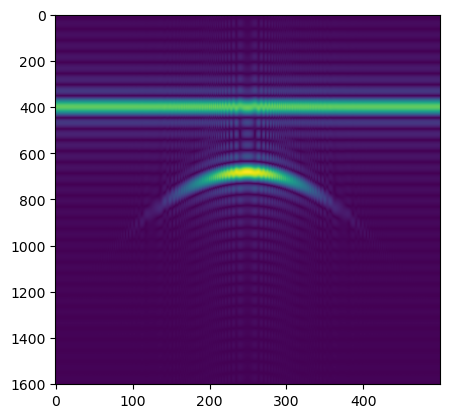

In [3]:
plt.imshow(np.abs(rdrgrm), aspect=0.3)
plt.show()

In [4]:
import sys, os
sys.path.append("../../src")
from focus import *

In [5]:
par = {
    'rx_window_offset':22.5e3,
    'rx_window_m':10e3,
}

In [6]:
sx = np.linspace(-10e3, 20e3, 500)
sz = 25e3
c1 = 299792458
c2 = c1 / np.sqrt(3.15)

t = (5000, 5050, -1000)

sampl = 48e6   # sampling rate [MHz]
wavlen = 33.3  # wavelength    [m]

rb = int((par['rx_window_m'] / c1) / (1 / sampl))
dm = c1 / (sampl)

sltrng   = est_slant_range(sx, sz, t[0], t[2], c1, c2)
sltrng_t = 2 * 10**6 * sltrng / c1
slt_rb   = ((sltrng - par['rx_window_offset']) // dm).astype(int)

In [7]:
rdrgrm = rdrgrm[:, 1:-1]

Nr, Na = rdrgrm.shape

# --- 2. Range Cell Migration Correction (RCMC) ---
shift_amounts = slt_rb - np.min(slt_rb)
rolled_matrix = np.array([
    np.roll(rdrgrm[:, i], -int(shift_amounts[i]))
    for i in range(rdrgrm.shape[1])
]).T

# --- 3. Azimuth matched filter ---
k = (2 * np.pi) / (c1 / 9e6)
match_filter = np.exp(-2j * k * sltrng)

# --- 1. Azimuth FFT ---
fft_len = int(2.0 * Na)
pad = fft_len - Na

# Pad only at the end
rolled_matrix = np.pad(rolled_matrix, ((0, 0), (0, pad)), mode='constant')
match_filter = np.pad(match_filter, (0, pad), mode='constant')

# FFT along azimuth
az_fft = np.fft.fft(rolled_matrix, axis=1, n=fft_len)
H_az = np.fft.fft(match_filter, n=fft_len)

# Apply filter
focused_freq = az_fft * H_az[np.newaxis, :]

# --- 4. Inverse FFT ---
focused = np.fft.ifft(focused_freq, axis=1)

# Crop to original azimuth size (centered)
start = pad // 2
end = start + Na
focused = focused[:, start:end]

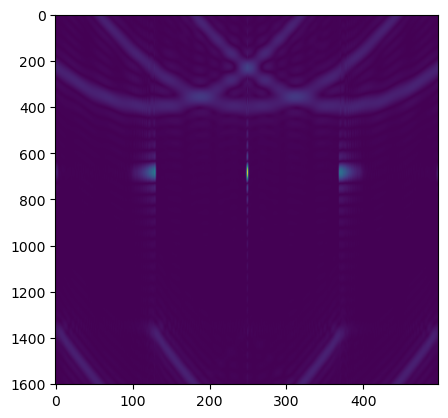

In [8]:
plt.imshow(np.abs(focused), aspect=0.3)
plt.show()

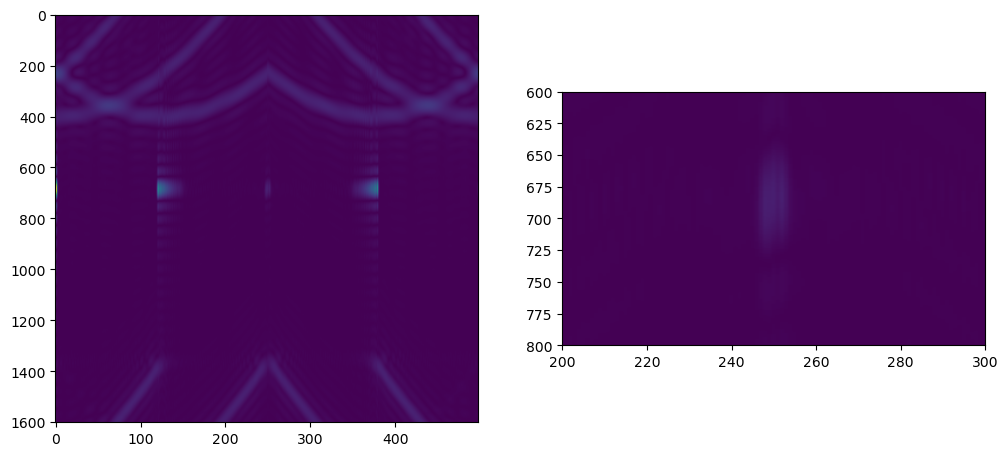

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(np.abs(np.roll(focused,250)), aspect=0.3)
ax[1].imshow(np.abs(np.roll(focused,250)), aspect=0.3)
ax[1].set_xlim(200, 300)
ax[1].set_ylim(800, 600)
plt.show()